In [23]:
import tensorflow
from tensorflow.keras import layers, models, applications
import matplotlib.pyplot as plt
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import class_weight

Verif que tensorflow fonctionne bien :

In [24]:
print("TensorFlow version:", tensorflow.__version__)
gpus = tensorflow.config.list_physical_devices('GPU')

if gpus:
    print(f"TensorFlow utilise : {gpus[0].name}")
    print("Détails :", gpus)
else:
    print("TensorFlow tourne sur le processeur (CPU).")

TensorFlow version: 2.20.0
TensorFlow utilise : /physical_device:GPU:0
Détails : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Verif du nombre d'images par races de chat

In [25]:
import os

target_dir = 'data/images' 

print(f"Comptage des images dans {target_dir}\n")

stats = {}

if os.path.exists(target_dir):
    for race in os.listdir(target_dir):
        race_path = os.path.join(target_dir, race)
        if os.path.isdir(race_path):
            count = len(os.listdir(race_path))
            stats[race] = count

    # Tri et affichage des stats
    for race, count in sorted(stats.items(), key=lambda item: item[1], reverse=True):
        print(f"{race.ljust(25)} : {count} images")
else:
    print(f"Le dossier {target_dir} n'existe pas !")

Comptage des images dans data/images

Domestic Short Hair       : 53027 images
Domestic Medium Hair      : 5482 images
American Shorthair        : 5295 images
Domestic Long Hair        : 4499 images
Persian                   : 4018 images
Tortoiseshell             : 3963 images
Calico                    : 3468 images
Torbie                    : 3396 images
Dilute Calico             : 3230 images
Tuxedo                    : 3181 images
Dilute Tortoiseshell      : 3152 images
Tabby                     : 3012 images
Siamese                   : 2888 images
Ragdoll                   : 2669 images
Bengal                    : 2477 images
Tiger                     : 2256 images
Manx                      : 2059 images
Russian Blue              : 1870 images
Bombay                    : 1835 images
Snowshoe                  : 1625 images
Maine Coon                : 1418 images
Himalayan                 : 1301 images
Extra-Toes Cat - Hemingway Polydactyl : 1184 images
American Bobtail          : 9

In [26]:
data_dir = 'data/images'

BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH = 224

SELECTED_CLASSES = [
    'Abyssinian',
    'Bengal',
    'Birman',
    'Bombay',
    'British Shorthair',
    'Egyptian Mau',
    'Maine Coon',
    'Persian',
    'Ragdoll',
    'Russian Blue',
    'Siamese',
    'Sphynx - Hairless Cat'
]

print(f"Chargement des images depuis : {data_dir}")

train_ds = tensorflow.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  class_names=SELECTED_CLASSES,
  image_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE
)

val_ds = tensorflow.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  class_names=SELECTED_CLASSES,
  image_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(f"\nRaces trouvées ({len(class_names)}) : {class_names}")

Chargement des images depuis : data/images
Found 18738 files belonging to 12 classes.
Using 14991 files for training.
Found 18738 files belonging to 12 classes.
Using 3747 files for validation.

Races trouvées (12) : ['Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British Shorthair', 'Egyptian Mau', 'Maine Coon', 'Persian', 'Ragdoll', 'Russian Blue', 'Siamese', 'Sphynx - Hairless Cat']


In [ ]:
train_labels = []
class_names = train_ds.class_names

print("Calcul des poids (cela peut prendre quelques secondes)...")

for i, class_name in enumerate(class_names):
    path = os.path.join(data_dir, class_name)
    count = len(os.listdir(path))
    train_labels.extend([i] * count)

train_labels = np.array(train_labels)

# Calcul des poids avec skLearn
class_weights_values = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Conversion en dictionnaire pour Keras
class_weights = dict(enumerate(class_weights_values))

print(f"Poids calculés !")
print(f"Poids pour la classe la plus fréquente ({class_names[np.argmin(class_weights_values)]}) : {min(class_weights_values):.2f}")
print(f"Poids pour la classe la plus rare ({class_names[np.argmax(class_weights_values)]}) : {max(class_weights_values):.2f}")

Calcul des poids (cela peut prendre quelques secondes)...
✅ Poids calculés !
- Poids pour la classe la plus fréquente (Persian) : 0.39
- Poids pour la classe la plus rare (Sphynx - Hairless Cat) : 7.47


Création de variations aléatoire des images pour éviter l'apprentissage par coeur du modèle (data augmentation)

In [31]:
data_augmentation = tensorflow.keras.Sequential([
  layers.RandomFlip("horizontal", input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

In [35]:
nbr_classes = len(class_names)

model = models.Sequential([
  data_augmentation,
  
  # Normalisation entre 0 et 1
  layers.Rescaling(1./255),
  
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  
  layers.Dropout(0.2),
  
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(nbr_classes, activation='softmax')
])

model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_7 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_7 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,447,788 (24.60 MB)

 Trainable params: 6,447,788 (24.60 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# Entrainement du modèle
epochs = 10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  class_weight=class_weights
)

Epoch 1/10


E0000 00:00:1769726706.086442    6983 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_9_1/dropout_6_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


469/469 ━━━━━━━━━━━━━━━━━━━━ 56s 109ms/step - accuracy: 0.1809 - loss: 2.3787 - val_accuracy: 0.2469 - val_loss: 2.1634
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - accuracy: 0.2552 - loss: 2.2562 - val_accuracy: 0.2594 - val_loss: 2.1103
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 56ms/step - accuracy: 0.2871 - loss: 2.1767 - val_accuracy: 0.2805 - val_loss: 2.1172
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - accuracy: 0.3041 - loss: 2.1377 - val_accuracy: 0.2882 - val_loss: 2.0802
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - accuracy: 0.3161 - loss: 2.0977 - val_accuracy: 0.3106 - val_loss: 2.0714
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - accuracy: 0.3256 - loss: 2.0664 - val_accuracy: 0.3179 - val_loss: 2.0101
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.3307 - loss: 2.0280 - val_accuracy: 0.3397 - val_loss: 1.9897
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 59ms/step - accuracy: 0.3386 - loss: 2.0166 - val_accura

In [34]:
# Sauvegarde du modèle
model.save('backend/model/model_custom.keras')
print("Le modèle a bien été sauvegardé.")

Le modèle a bien été sauvegardé.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


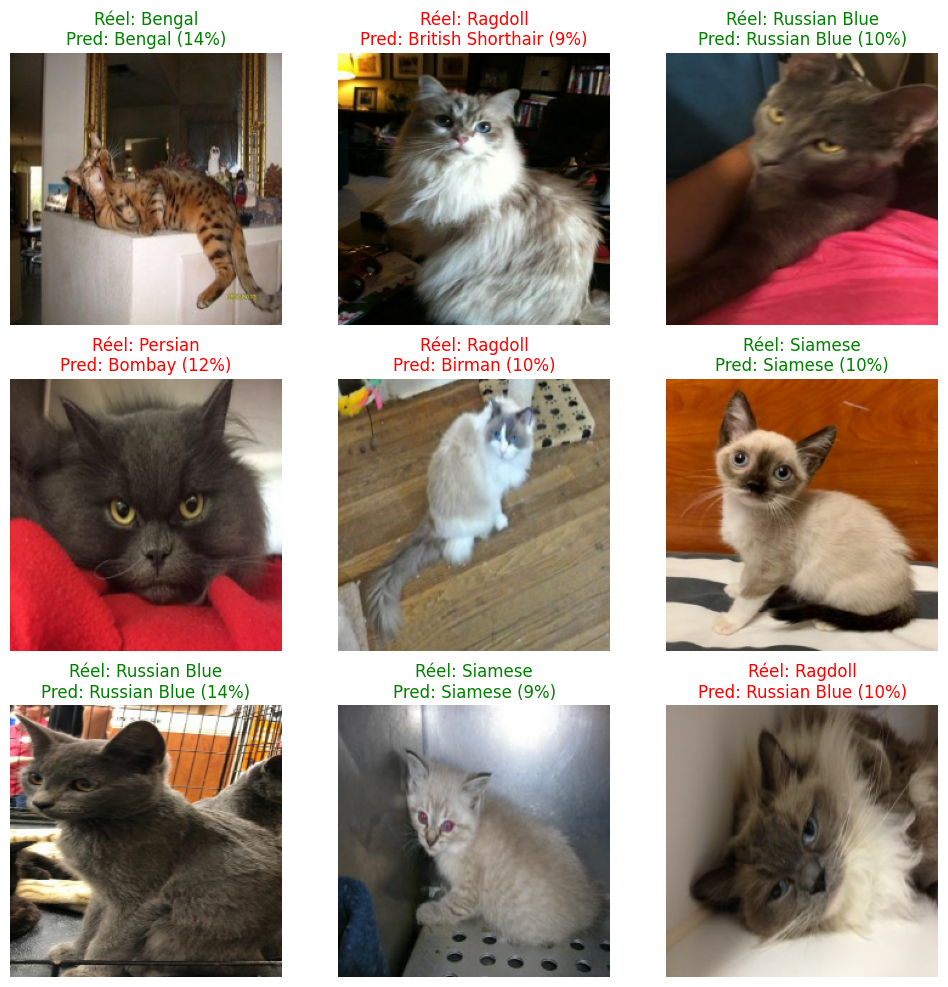

In [37]:
# lot d'images de validation
image_batch, label_batch = next(iter(val_ds))

# Prédictions
predictions = model.predict(image_batch)

# Affichage des résultats
plt.figure(figsize=(12, 12))
for i in range(9):
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(image_batch[i].numpy().astype("uint8"))
  
  # Calcul du score
  scores = tensorflow.nn.softmax(predictions[i])
  predicted_class = class_names[np.argmax(scores)]
  confidence = 100 * np.max(scores)
  
  real_class = class_names[label_batch[i]]
  
  color = 'green' if predicted_class == real_class else 'red'
  
  plt.title(f"Réel: {real_class}\nPred: {predicted_class} ({confidence:.0f}%)", color=color)
  plt.axis("off")

plt.show()

## Approche transfert learning

In [ ]:
base_model = applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

base_model.trainable = False

model_tl = models.Sequential([
    layers.RandomFlip("horizontal", input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    
    base_model,
    
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    
    layers.Dense(nbr_classes, activation='softmax')
])

model_tl.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Modèle EfficientNetB0 construit !")

Modèle EfficientNetB0 construit !


In [ ]:
# Entrainement
early_stopping = tensorflow.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True
)

print("Lancement du Transfer Learning...")

history_tl = model_tl.fit(
  train_ds,
  validation_data=val_ds,
  epochs=10,
  callbacks=[early_stopping],
  class_weight=class_weights
)

print("Terminé !")

Lancement du Transfer Learning...
Epoch 1/10


469/469 ━━━━━━━━━━━━━━━━━━━━ 72s 121ms/step - accuracy: 0.5994 - loss: 1.4185 - val_accuracy: 0.7275 - val_loss: 0.8765
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 53s 113ms/step - accuracy: 0.6609 - loss: 1.1089 - val_accuracy: 0.7206 - val_loss: 0.8447
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 53s 114ms/step - accuracy: 0.6809 - loss: 1.0301 - val_accuracy: 0.7302 - val_loss: 0.8276
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 54s 116ms/step - accuracy: 0.6897 - loss: 0.9796 - val_accuracy: 0.7358 - val_loss: 0.7934
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 57s 123ms/step - accuracy: 0.7018 - loss: 0.9383 - val_accuracy: 0.7339 - val_loss: 0.7905
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 54s 116ms/step - accuracy: 0.6976 - loss: 0.9203 - val_accuracy: 0.7313 - val_loss: 0.8023
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 54s 116ms/step - accuracy: 0.7047 - loss: 0.9039 - val_accuracy: 0.7374 - val_loss: 0.7764
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 54s 116ms/step - accuracy: 0.7104 - loss: 0.8871 - val

Dégel du modele et re-compilation

In [ ]:
base_model.trainable = True

# On utilise les 30 dernières couches pour l'ajustement.
for layer in base_model.layers[:-30]:
    layer.trainable = False

optimizer_fine = tensorflow.keras.optimizers.Adam(learning_rate=1e-4)

model_tl.compile(
    optimizer=optimizer_fine,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Modèle dégelé et prêt pour le Fine-Tuning!")
print(f"Nombre de couches dans EfficientNet : {len(base_model.layers)}")
print("Seules les 30 dernières vont s'entraîner.")

✅ Modèle dégelé et prêt pour le Fine-Tuning !
Nombre de couches dans EfficientNet : 238
Seules les 30 dernières vont s'entraîner.


Reprise de l'entrainement (fine tuning)

In [ ]:
fine_tune_epochs = 15
total_epochs =  len(history_tl.history['loss']) + fine_tune_epochs

print(f"🚀 Démarrage du Fine-Tuning (de l'époque {len(history_tl.history['loss'])} à {total_epochs})...")

history_fine = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    # On reprend là ou il s'etait arreté
    initial_epoch=history_tl.epoch[-1], 
    epochs=total_epochs,
    class_weight=class_weights 
)

🚀 Démarrage du Fine-Tuning (de l'époque 10 à 25)...
Epoch 10/25


E0000 00:00:1769728841.895255    6983 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_10_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


469/469 ━━━━━━━━━━━━━━━━━━━━ 94s 156ms/step - accuracy: 0.7132 - loss: 0.8304 - val_accuracy: 0.7267 - val_loss: 0.7906
Epoch 11/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 69s 148ms/step - accuracy: 0.7416 - loss: 0.7261 - val_accuracy: 0.7489 - val_loss: 0.7568
Epoch 12/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 70s 149ms/step - accuracy: 0.7561 - loss: 0.6541 - val_accuracy: 0.7478 - val_loss: 0.7576
Epoch 13/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 70s 148ms/step - accuracy: 0.7769 - loss: 0.5908 - val_accuracy: 0.7561 - val_loss: 0.7236
Epoch 14/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 70s 150ms/step - accuracy: 0.7843 - loss: 0.5616 - val_accuracy: 0.7598 - val_loss: 0.7267
Epoch 15/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 72s 153ms/step - accuracy: 0.7990 - loss: 0.5162 - val_accuracy: 0.7699 - val_loss: 0.7099
Epoch 16/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 70s 149ms/step - accuracy: 0.8150 - loss: 0.4645 - val_accuracy: 0.7734 - val_loss: 0.7047
Epoch 17/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 70s 149ms/step - accuracy: 0.8204 - loss: 0.436

In [45]:
# Sauvegarde du modèle
model_tl.save('backend/model/model_tl.keras')
print("Le modèle a bien été sauvegardé.")

Le modèle a bien été sauvegardé.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


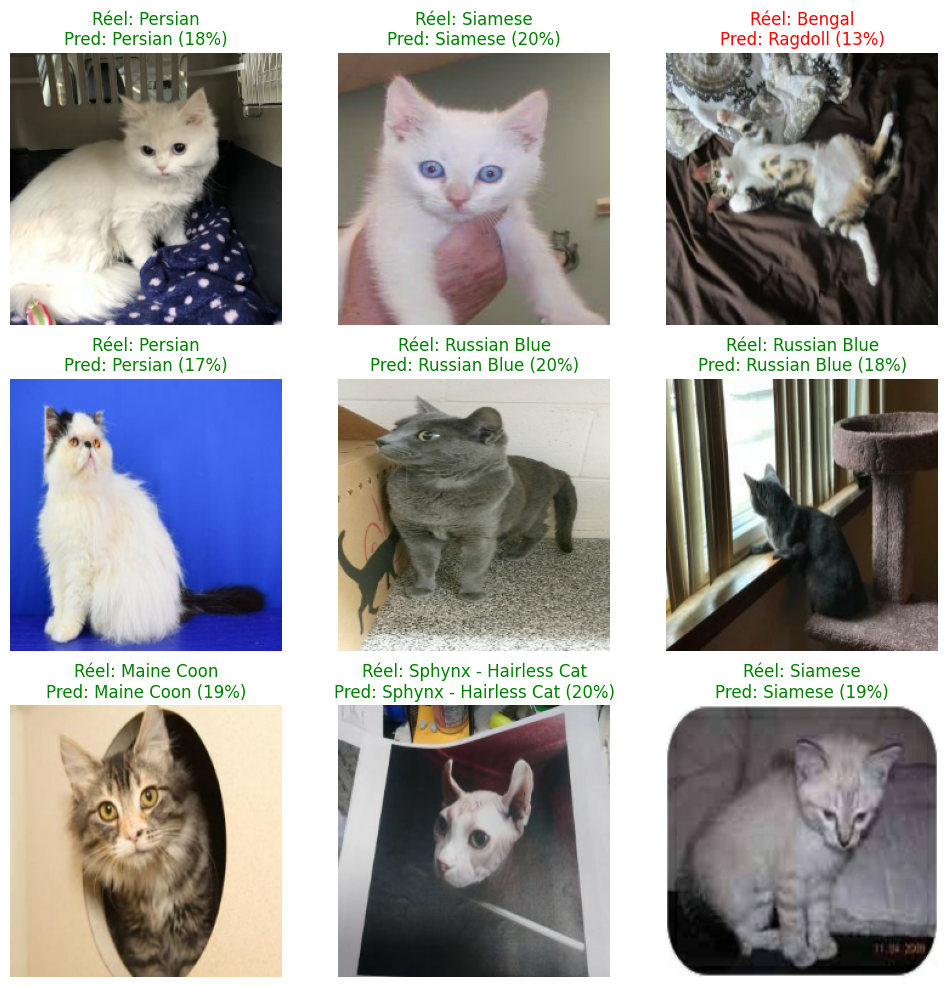

In [47]:
# lot d'images de validation
image_batch, label_batch = next(iter(val_ds))

# Prédictions
predictions = model_tl.predict(image_batch)

# Affichage des résultats
plt.figure(figsize=(12, 12))
for i in range(9):
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(image_batch[i].numpy().astype("uint8"))
  
  # Calcul du score
  scores = tensorflow.nn.softmax(predictions[i])
  predicted_class = class_names[np.argmax(scores)]
  confidence = 100 * np.max(scores)
  
  real_class = class_names[label_batch[i]]
  
  color = 'green' if predicted_class == real_class else 'red'
  
  plt.title(f"Réel: {real_class}\nPred: {predicted_class} ({confidence:.0f}%)", color=color)
  plt.axis("off")

plt.show()